## Imports

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

---
## Fonction de simulation

In [ ]:
def run_simulation(omega, E, rho, L, Nx, Nt, t_end, N, M):
    
    c = np.sqrt(E/rho)
    omega_bar=omega*L/c
    x  = np.linspace(0, L, Nx)
    x_bar=x/L
    dx = x[1] - x[0]
    dx_bar=dx/L
    dt = t_end / Nt

    dt_bar=dt*(c/L)

    CFL = c * dt / dx
    assert CFL <= 1.0, f"CFL={CFL:.3f} > 1 : schéma instable"

    CFL_bar= dt_bar/dx_bar
    
    t_pulse_bar = 2 * np.pi / omega_bar     #The period T

    def u_bar_right(t):             #u_bar=u/A
        if t < t_pulse_bar:
            return np.sin(omega_bar * t)
        else:
            return 0.0  

    u_bar     = np.zeros(Nx)
    u_bar_dot = np.zeros(Nx)
    u_bar_2=np.zeros(Nx)

    u_bar_storage         = np.zeros((Nt+1, Nx))
    u_bar_dot_storage     = np.zeros((Nt, Nx))
    u_bar_xx_storage      = np.zeros((Nt, Nx))
    delta_u_bar_storage   = np.zeros((Nt, Nx))

    u_bar_storage[0] = u_bar.copy()

    # --- Boucle de simulation ---
    for n in range(Nt):
        tn_bar = n * dt_bar

        u_bar_dot = np.zeros(Nx)
        u_bar_xx = np.zeros(Nx)
        u_bar_new = np.zeros(Nx)

        u_bar_xx[1:-1] = ((u_bar[2:] - 2*u_bar[1:-1] + u_bar[:-2]) / dx_bar**2)
        u_bar_new[1:-1] = 2.0 * u_bar[1:-1] - u_bar_2[1:-1] + (CFL_bar)**2 * (u_bar[2:] - 2.0 * u_bar[1:-1] + u_bar[:-2])
        u_bar_dot[1:-1] = (u_bar[1:-1] - u_bar_2[1:-1]) / dt_bar

        u_bar_new[0] = 0       
        u_bar_dot[0] = 0          
        
        u_bar_xx[-1] = ((u_bar[-3] - 2*u_bar[-2] + u_bar[-1]) / dx_bar**2)
        u_bar_new[-1] = u_bar_right(tn_bar)
        u_bar_dot[-1] = (u_bar_new[-1] - u_bar_2[-1]) / (2.0 * dt_bar) 
        
        u_bar_dot_storage[n]   = u_bar_dot
        u_bar_xx_storage[n]    = u_bar_xx
        delta_u_bar_storage[n] = u_bar_new - u_bar

        # Passage au pas de temps suivant
        u_bar_2 = u_bar.copy()
        u_bar   = u_bar_new
        u_bar_storage[n+1] = u_bar.copy()

    rows=[]

    def past_label(k):
        if k==0: return "@t"
        if k==1: return "@t-dt"
        return f"@t-{k}dt"

    # --- Construction du dataset ---
    ndt=1       # Number of dt in the future to be predicted
    
    for n in range(N-1, Nt-M+1):
        for j in range(1, Nx-1):
            row={"omega_bar":omega_bar}

            #Inputs
            for k in range(N):
                row[f"u_dot{past_label(k)}"]=u_bar_dot_storage[n-k,j]
                row[f"u_xx{past_label(k)}"]=u_bar_xx_storage[n-k,j]

            #Outputs
            for k in range(M):
                row[f"delta_u@{k+1}dt"]=delta_u_bar_storage[n+k,j]
            
            #row[f"delta_u@{k+1}dt"]=u_bar_storage[n+ndt,j]-u_bar_storage[n,j]
            
            rows.append(row)
            

    return pd.DataFrame(rows), u_bar_storage, x

## Génération du dataset complet

In [14]:
all_dfs = []

#Parameters
E=1
rho=2
L=1
c = np.sqrt(E/rho)
Nt=300
Nx=100
t_end=3

X=8

N=3    #Moments in the past + moment t
M=1     #Moments in the future

PULSATIONS = np.linspace(7, 90, X).round(1).tolist()

n_sims=len(PULSATIONS)

# We compute each simulation
for idx, w in enumerate(PULSATIONS, start=1):
    df_run,_,_ = run_simulation(omega=w, E=E,rho=rho, L=L, Nt=Nt, Nx=Nx, t_end=t_end, N=N, M=M)
    all_dfs.append(df_run)

# We concatenate each simulation in the df which is the full dataset table
df = pd.concat(all_dfs, ignore_index=True)
print(df.head(0))


Empty DataFrame
Columns: [omega_bar, u_dot@t, u_xx@t, u_dot@t-dt, u_xx@t-dt, u_dot@t-2dt, u_xx@t-2dt, delta_u@1dt]
Index: []



## Split train / val / test

In [15]:
rng = np.random.default_rng(seed=42)

omega_bars=[w*L/c for w in PULSATIONS]
omega_bars_arr=rng.permutation(omega_bars)

n_train = int(0.70 * len(omega_bars))
n_val   = int(0.15 *  len(omega_bars))

train_combos = set( omega_bars_arr[:n_train])
val_combos   = set( omega_bars_arr[n_train:n_train + n_val])

def assign_split(ob):
    if ob in train_combos: return "train"
    if ob in val_combos:   return "val"
    return "test"

df["split"] = df["omega_bar"].map(assign_split)

print("Distribution du split :")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} lignes  ({100*n/len(df):.1f} %)")

Distribution du split :
  train :  146,020 lignes  (62.5 %)
  val   :   29,204 lignes  (12.5 %)
  test  :   58,408 lignes  (25.0 %)


## Normalisation (z-score)

In [16]:
def past_label(k):
    if k ==0: return "@t"
    if k==1: return "@t-dt"
    return f"@t-{k}dt"

INPUTS  = ([f"u_dot{past_label(k)}"    for k in range(N)]
         + [f"u_xx{past_label(k)}" for k in range(N)])
OUTPUTS = [f"delta_u@{k+1}dt" for k in range(M)]

print("INPUTS  :", INPUTS)
print("OUTPUTS :", OUTPUTS)

# Masque train pour calculer les stats uniquement sur le train set
train_mask = df["split"] == "train"

# Calcul des stats sur le train set uniquement
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # éviter division par 0

# Application à tout le dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Statistiques de normalisation (calculées sur train) :")
print(norm_stats.round(6))

INPUTS  : ['u_dot@t', 'u_dot@t-dt', 'u_dot@t-2dt', 'u_xx@t', 'u_xx@t-dt', 'u_xx@t-2dt']
OUTPUTS : ['delta_u@1dt']
Statistiques de normalisation (calculées sur train) :
                 mean          std
u_dot@t      0.002583    13.077581
u_dot@t-dt   0.005596    13.054520
u_dot@t-2dt  0.009086    13.031002
u_xx@t      -0.374007  1488.115047
u_xx@t-dt   -0.478223  1485.604378
u_xx@t-2dt  -0.508975  1483.045771
delta_u@1dt  0.000009     0.099762


---
## Sauvegarde

In [17]:
COLS_ORDER = (
    INPUTS                                   # inputs bruts
    + [c + "_n" for c in INPUTS]             # inputs normalisés
    + OUTPUTS                                # outputs bruts
    + [c + "_n" for c in OUTPUTS]            # outputs normalisés
    + ["split"]
)
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset sauvegardé : wave_beam_dataset.csv")
print(f"  {len(df):,} lignes × {len(df.columns)} colonnes")

# Stats de normalisation — à recharger dans les fichiers 2 et 3
norm_stats.to_csv("norm_stats.csv")
print(f"Stats de normalisation sauvegardées : norm_stats.csv")

Dataset sauvegardé : wave_beam_dataset.csv
  233,632 lignes × 15 colonnes
Stats de normalisation sauvegardées : norm_stats.csv


In [18]:
import json

params_simulation = {
    "L": L, "Nx": Nx, "Nt": Nt, "t_end": t_end,
    "E": E, "rho": rho,
    "PULSATIONS": PULSATIONS,
    "n_sims": n_sims,
    "N":N,
    "M":M,
    "INPUTS": INPUTS,
    "OUTPUTS": OUTPUTS,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Paramètres sauvegardés : params_simulation.json")

Paramètres sauvegardés : params_simulation.json


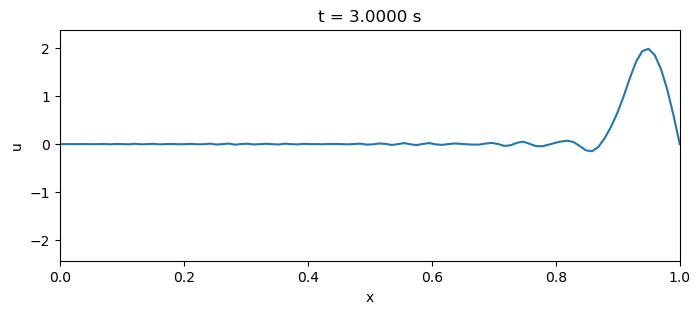

In [19]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Lance une simulation juste pour l'animation
A_demo, w_demo = 0.05, 20.0
_, u_storage, x = run_simulation(w_demo, E, rho, L, Nx, Nt, t_end, N, M)

fig, ax = plt.subplots(figsize=(8, 3))
line, = ax.plot(x, u_storage[0])
ax.set_xlim(0, L)
ax.set_ylim(u_storage.min()*1.2, u_storage.max()*1.2)
ax.set_xlabel("x"); ax.set_ylabel("u")
title = ax.set_title("")

def update(n):
    line.set_ydata(u_storage[n])
    title.set_text(f"t = {n * t_end/Nt:.4f} s")
    return line, title

ani = FuncAnimation(fig, update, frames=range(0, Nt+1, 2), interval=30, blit=True)
HTML(ani.to_jshtml())